In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.pyplot import imshow
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
%matplotlib inline
im = mpimg.imread(r"D:\friday_20_dataset\train\benign\benign_window_0001.png")
print(im.shape)
imshow(im)


(554, 465, 4)


In [4]:
image_height = 64
image_width = 64
image_size = (image_height,image_width)
batch_size = 32

train_datagen = ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_directory(
     r"D:\friday_20_dataset\train",
     target_size=image_size,
     batch_size=batch_size,
     class_mode='binary',
     shuffle=True
)
val_generator = train_datagen.flow_from_directory(
    r"D:\friday_20_dataset\val",
    target_size=image_size,
    batch_size=batch_size,
    class_mode='binary',  
    shuffle=False
)       

Found 5123 images belonging to 2 classes.
Found 718 images belonging to 2 classes.


In [5]:
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    r"D:\friday_20_dataset\test",         
    target_size=image_size,
    batch_size=batch_size,
    class_mode='binary',
    # classes=['benign', 'ddos'],
    shuffle=False
)   

Found 1552 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, BatchNormalization, Dropout, InputLayer, GaussianNoise

t_model = keras.models.Sequential()
t_model.add(InputLayer(shape = (image_height, image_width,3)))
t_model.add(GaussianNoise(0.05))

t_model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
t_model.add(MaxPooling2D(pool_size=(2, 2)))
t_model.add(Dropout(0.4))

t_model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
t_model.add(MaxPooling2D(pool_size=(2, 2)))
t_model.add(Dropout(0.4))

t_model.add(Flatten())
t_model.add(Dense(128, activation='relu'))
t_model.add(Dropout(0.5))

t_model.add(Dense(1, activation='sigmoid'))
t_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ laplace_noise (LaplaceNoise)    │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,801 (8.07 MB)

 Trainable params: 2,116,801 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
from keras.optimizers import Adam

t_model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy',metrics=['accuracy', 
             keras.metrics.Precision(),
             keras.metrics.Recall()]
               )

In [9]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

y = train_generator.classes                  
classes = np.unique(y)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y
)

class_weight_dict = {c: w for c, w in zip(classes, weights)}
print("Class weights:", class_weight_dict) 

Class weights: {np.int32(0): np.float64(1.206547338671691), np.int32(1): np.float64(0.8538333333333333)}


In [10]:
from tensorflow.keras.callbacks import EarlyStopping

callback = EarlyStopping(
    monitor='val_loss',           
    patience=5,                   
    restore_best_weights=True,    
    verbose=1                     
)

In [11]:
history = t_model.fit(train_generator, validation_data=val_generator, class_weight=class_weight_dict, epochs=30, callbacks=[callback],verbose=1) #validation_data=val_generator,

Epoch 1/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 34s 195ms/step - accuracy: 0.9496 - loss: 0.1374 - precision: 0.9528 - recall: 0.9617 - val_accuracy: 0.9735 - val_loss: 0.0762 - val_precision: 1.0000 - val_recall: 0.9683
Epoch 2/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 37s 170ms/step - accuracy: 0.9799 - loss: 0.0561 - precision: 0.9782 - recall: 0.9877 - val_accuracy: 0.9847 - val_loss: 0.0852 - val_precision: 1.0000 - val_recall: 0.9817
Epoch 3/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 29s 181ms/step - accuracy: 0.9850 - loss: 0.0361 - precision: 0.9864 - recall: 0.9880 - val_accuracy: 0.9708 - val_loss: 0.0606 - val_precision: 1.0000 - val_recall: 0.9650
Epoch 4/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 31s 191ms/step - accuracy: 0.9898 - loss: 0.0271 - precision: 0.9900 - recall: 0.9927 - val_accuracy: 0.9903 - val_loss: 0.0298 - val_precision: 1.0000 - val_recall: 0.9883
Epoch 5/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 32s 198ms/step - accuracy: 0.9953 - loss: 0.0158 - precision: 0.9960 - recall: 0.9960 - val_accuracy: 0.9889

In [12]:
metrics = t_model.evaluate(val_generator)
print("loss:",metrics[0] )
print("Accuracy:", metrics[1])

23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 119ms/step - accuracy: 1.0000 - loss: 0.0052 - precision: 1.0000 - recall: 1.0000            
loss: 0.005164779722690582
Accuracy: 1.0


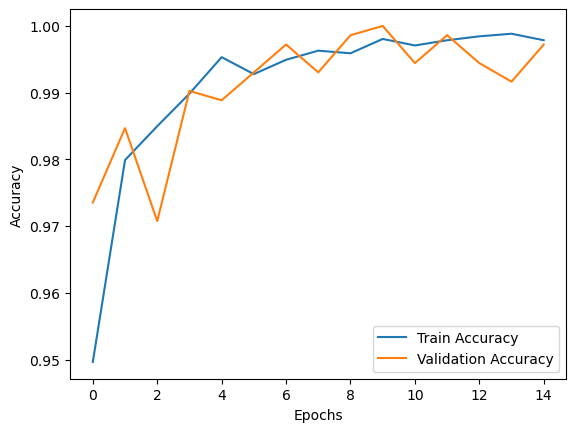

In [18]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['Train Accuracy', 'Validation Accuracy'])
plt.show()

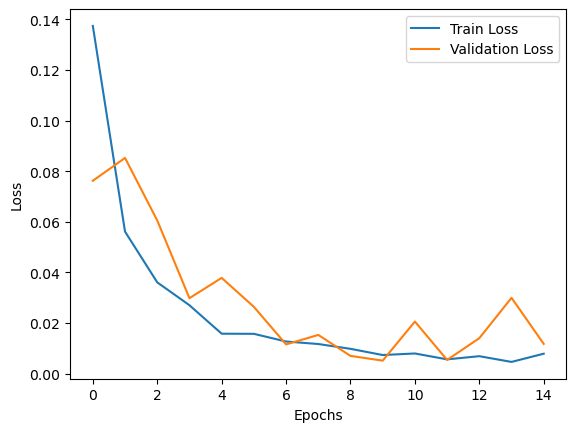

In [19]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['Train Loss', 'Validation Loss'])
plt.show()

49/49 ━━━━━━━━━━━━━━━━━━━━ 10s 201ms/step - accuracy: 0.9948 - loss: 0.0346 - precision: 0.9985 - recall: 0.9955           
Test Accuracy: 0.9948
Test Loss: 0.0346
Test Precision: 0.9985
Test Recall: 0.9955
49/49 ━━━━━━━━━━━━━━━━━━━━ 10s 201ms/step

Confusion Matrix:
[[ 207    2]
 [   6 1337]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.97      0.99      0.98       209
        DDoS       1.00      1.00      1.00      1343

    accuracy                           0.99      1552
   macro avg       0.99      0.99      0.99      1552
weighted avg       0.99      0.99      0.99      1552



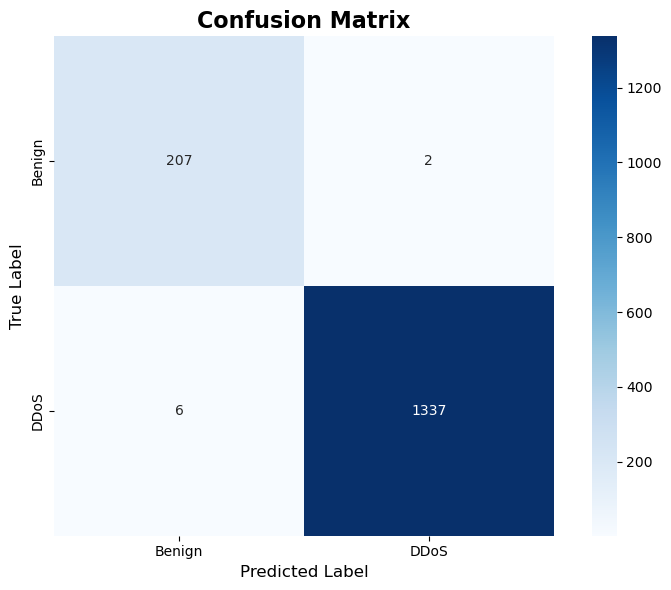

In [20]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

test_generator.reset()
final_results = t_model.evaluate(test_generator, verbose=1)

print(f"Test Accuracy: {final_results[1]:.4f}")
print(f"Test Loss: {final_results[0]:.4f}")
print(f"Test Precision: {final_results[2]:.4f}")
print(f"Test Recall: {final_results[3]:.4f}")

y_pred = t_model.predict(test_generator)
y_pred_classes = (y_pred > 0.5).astype(int).flatten()
y_true = test_generator.classes

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred_classes))
print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=['Benign', 'DDoS']))


cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Benign', 'DDoS'],
            yticklabels=['Benign', 'DDoS'],
            cbar=True, 
            square=True,
            )

plt.title('Confusion Matrix', fontsize=16, weight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

In [21]:
t_model.save("cnn_model_22_11.keras")